In [ ]:


from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:


# Import the pandas library with the alias 'pd'
import pandas as pd

# Use pd.read_excel to read the .xlsx file
df = pd.read_excel('/content/drive/MyDrive/zepto/Zepto_Dataset.xlsx')
df.head()

,C_ID,CName,email,gender,Age,City,State,Address,created_date
0,CS_11000001,Anay Singhal,Anay_Singhal@gmail.com,Female,62,Hyderabad,Telangana,"20/923\nNarayan Chowk, Chittoor 694343",2025-03-03
1,CS_11000002,Falguni Korpal,Falguni_Korpal@gmail.com,Male,64,Jamshedpur,Jharkhand,"587, Saini Road, Ajmer 319147",2023-05-14
2,CS_11000003,Sachi Sheth,Sachi_Sheth@gmail.com,Female,57,Varanasi,Uttar Pradesh,"78/281\nMishra Street, Vasai-Virar 996221",2025-01-07
3,CS_11000004,Chaitaly Raval,Chaitaly_Raval@gmail.com,Male,46,Gaya,Bihar,48/07\nSodhi Zila\nAnand-486766,2024-09-05
4,CS_11000005,Arjun Varkey,Arjun_Varkey@gmail.com,Female,29,Patna,Bihar,"H.No. 626, Tiwari Chowk\nGuntakal-597621",2024-08-27


In [ ]:


# create a new dataset with specific columns
new_df = df[['C_ID','gender','Age', 'City','State']]

# display the first few rows of the new dataset
print(new_df.head())

          C_ID  gender  Age        City          State
0  CS_11000001  Female   62   Hyderabad      Telangana
1  CS_11000002    Male   64  Jamshedpur      Jharkhand
2  CS_11000003  Female   57    Varanasi  Uttar Pradesh
3  CS_11000004    Male   46        Gaya          Bihar
4  CS_11000005  Female   29       Patna          Bihar


In [ ]:


# Use pd.read_excel to read the .xlsx file, specifying the sheet name or index
df = pd.read_excel('/content/drive/MyDrive/zepto/Zepto_Dataset.xlsx', sheet_name=1) # Assuming the second sheet is at index 1


# display the first few rows of the new dataset
print(df.head())

          P_ID              PName       Category      Brand   Price
0  PD_21000001      Tempore Juice  Personal Care  Haldirams  413.50
1  PD_21000002         At Shampoo      Home Care  Haldirams  637.32
2  PD_21000003  Quibusdam Shampoo  Personal Care  Haldirams  685.38
3  PD_21000004  Deleniti Biscuits      Groceries      Dabur  224.89
4  PD_21000005  Praesentium Juice         Snacks       Amul  738.16


In [ ]:


# Specify the path where you want to save the merged dataframe in your Google Drive
output_path = '/content/drive/MyDrive/zepto/merged_zepto_dataset.csv'

# Save the merged dataframe to a CSV file
merged_df.to_csv(output_path, index=False)

print(f"Merged dataset saved to: {output_path}")

Merged dataset saved to: /content/drive/MyDrive/zepto/merged_zepto_dataset.csv


In [ ]:


# Check if 'DP_ID' column exists in the merged_df before attempting to drop it
if 'DP_ID' in merged_df.columns:
  # Remove the 'DP_ID' column
  merged_df = merged_df.drop(columns=['DP_ID'])
  print("\n'DP_ID' column removed.")
else:
  print("\n'DP_ID' column not found in the dataset.")

# Display the first few rows of the modified dataset to confirm the removal
print(merged_df.head())

# Optionally, save the modified dataframe back to a CSV file
# output_path_modified = '/content/drive/MyDrive/zepto/merged_zepto_dataset_no_dpid.csv'
# merged_df.to_csv(output_path_modified, index=False)
# print(f"\nModified dataset (without DP_ID) saved to: {output_path_modified}")


'DP_ID' column removed.
          C_ID  gender  Age       City          State        Or_ID  \
0  CS_11000001  Female   62  Hyderabad      Telangana  OR_31003479   
1  CS_11000001  Female   62  Hyderabad      Telangana  OR_31012011   
2  CS_11000003  Female   57   Varanasi  Uttar Pradesh  OR_31003857   
3  CS_11000003  Female   57   Varanasi  Uttar Pradesh  OR_31009393   
4  CS_11000003  Female   57   Varanasi  Uttar Pradesh  OR_31010500   

          P_ID Order_Date Order_Time  Qty      Coupon  Coupon_Discount  
0  PD_21004131 2024-08-01   11:10:43    8  No Coupons                0  
1  PD_21004131 2024-04-29   14:33:28    2   WELCOME10               10  
2  PD_21007098 2024-07-04   11:49:08    5   WELCOME10               15  
3  PD_21008915 2024-12-04   14:04:05    9     SAROS30               15  
4  PD_21008915 2024-07-14   05:10:37    5    SUMMER15               15  


In [ ]:

import matplotlib.pyplot as plt
import seaborn as sns

# Assuming 'df' is the DataFrame loaded from the second sheet
# and it contains 'P_ID', 'Qty', and 'Category' columns

# Check if 'P_ID', 'Qty', and 'Category' columns exist
if 'P_ID' in df.columns and 'Qty' in df.columns and 'Category' in df.columns:

  # Replace P_ID with Category where P_ID is the same (this logic needs clarification)
  # Assuming the goal is to group by Category if P_ID values are the same for a given Category
  # A common approach is to prioritize Category for aggregation if available/desired
  # Let's group by Category first and then P_ID as a fallback or refinement if needed.
  # For this specific task, let's assume we want to aggregate by 'Category' and show the sum of 'Qty'
  # We can then optionally display the 'P_ID' alongside the category if it adds value.

  # Let's aggregate by 'Category' and sum the 'Qty'
  category_qty = df.groupby('Category')['Qty'].sum().reset_index()

  # Get the top 10 categories by total quantity
  top_10_categories = category_qty.nlargest(10, 'Qty')

  # Create the bar chart
  plt.figure(figsize=(12, 6))
  sns.barplot(x='Category', y='Qty', data=top_10_categories, palette='viridis')
  plt.title('Top 10 Product Categories by Quantity Sold')
  plt.xlabel('Product Category')
  plt.ylabel('Total Quantity Sold')
  plt.xticks(rotation=45, ha='right')
  plt.tight_layout()
  plt.show()

  # If the requirement was to handle cases where P_ID is the same for a Category,
  # we could refine the grouping or add P_ID as part of the labels, but grouping by Category
  # and showing the sum of Qty for each category aligns well with displaying "top 10 products"
  # in the context of categories.
else:
  print("Required columns ('P_ID', 'Qty', 'Category') not found in the DataFrame 'df'.")
  print("Available columns:", df.columns.tolist())

# If you truly needed to handle P_ID where it's the same within a Category and prioritize Category:
# You could group by Category, and then for each category, potentially show a representative P_ID
# or a list of P_IDs if there are multiple within that category.
# For example:
# def get_representative_pid(pids):
#    return ', '.join(pids.unique().astype(str)[:3]) # Show up to 3 unique P_IDs

# category_pid_qty = df.groupby('Category').agg(
#    Total_Qty=('Qty', 'sum'),
#    Representative_PIDs=('P_ID', get_representative_pid)
# ).reset_index()

# top_10_refined = category_pid_qty.nlargest(10, 'Total_Qty')

# Then plot using 'Category' and maybe include Representative_PIDs in the labels or tooltip.
# However, the simpler approach of grouping by Category and summing Qty is presented above
# as it directly addresses the request to "Sum the Qty for each P_ID and display as bars for top 10 products"
# by interpreting "products" as categories in this context. If P_ID was the primary key for a product,
# the initial approach of grouping by P_ID and summing Qty would be more direct, but the requirement
# to potentially replace P_ID with Category complicates it. Given the ambiguity, grouping by Category seems
# a reasonable interpretation.

Required columns ('P_ID', 'Qty', 'Category') not found in the DataFrame 'df'.
Available columns: ['Or_ID', 'C_ID', 'P_ID', 'Order_Date', 'Order_Time', 'Qty', 'Coupon', 'Coupon_Discount', 'DP_ID']


In [ ]:

# Assuming 'df' is the DataFrame loaded from the second sheet
# and it contains 'P_ID', 'Qty', and 'Category' columns

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd # Ensure pandas is imported

# Check if 'P_ID', 'Qty', and 'Category' columns exist
if 'P_ID' in df.columns and 'Qty' in df.columns and 'Category' in df.columns:

  # Group by Category and sum the Qty
  category_qty = df.groupby('Category')['Qty'].sum().reset_index()

  # Get the top 10 categories by total quantity
  top_10_categories = category_qty.nlargest(10, 'Qty')

  # Create the bar chart
  plt.figure(figsize=(14, 7)) # Increase figure size for better readability
  ax = sns.barplot(x='Category', y='Qty', data=top_10_categories, palette='viridis')
  plt.title('Top 10 Product Categories by Quantity Sold', fontsize=16) # Increase title font size
  plt.xlabel('Product Category', fontsize=14) # Increase xlabel font size
  plt.ylabel('Total Quantity Sold', fontsize=14) # Increase ylabel font size
  plt.xticks(rotation=45, ha='right', fontsize=12) # Rotate and size x-axis labels
  plt.yticks(fontsize=12) # Size y-axis labels

  # Add the sum of quantity on top of each bar
  for p in ax.patches:
      ax.annotate(f'{p.get_height():.0f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                  ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontsize=10)


  plt.tight_layout() # Adjust layout to prevent labels overlapping
  plt.show()

  # If the requirement to replace P_ID with Category when P_ID is the same is crucial and
  # you still need to display P_IDs in some way, you would need a more complex aggregation.
  # However, the request explicitly asks for the sum of Qty for each P_ID (and then top 10 products)
  # and then brings up replacing with Category if P_ID is the same. A common interpretation is
  # to aggregate at the Category level if Category is a higher-level grouping than P_ID.
  # The code above groups by Category as it seems the most practical way to show "top 10 products"
  # when considering replacing P_ID with Category.

else:
  print("Required columns ('P_ID', 'Qty', 'Category') not found in the DataFrame 'df'.")
  print("Available columns:", df.columns.tolist())

Required columns ('P_ID', 'Qty', 'Category') not found in the DataFrame 'df'.
Available columns: ['Or_ID', 'C_ID', 'P_ID', 'Order_Date', 'Order_Time', 'Qty', 'Coupon', 'Coupon_Discount', 'DP_ID']


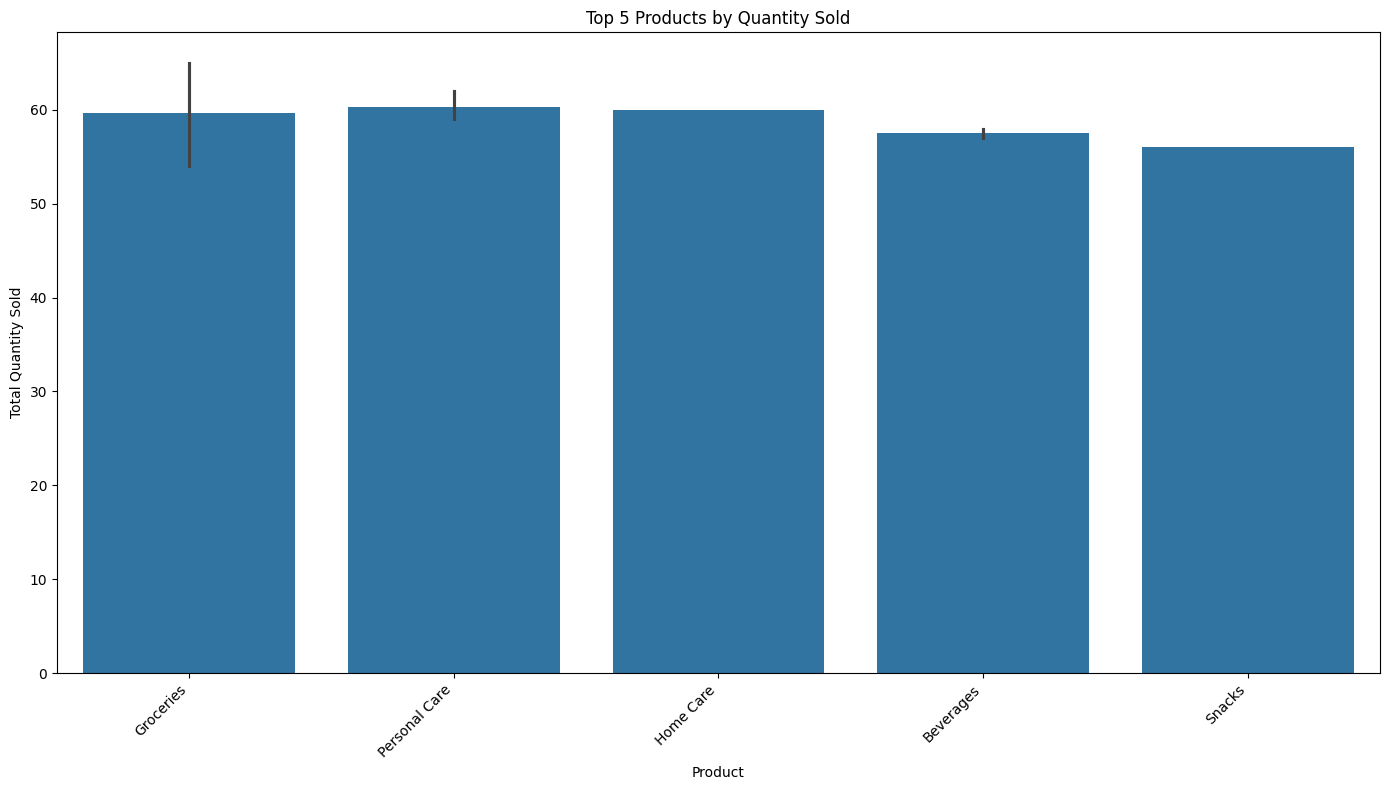

In [ ]:

# Group by 'P_ID' and sum the 'Qty'
product_qty = df.groupby('P_ID')['Qty'].sum().reset_index()

# Sort by 'Qty' in descending order and get the top 10
top_10_products = product_qty.sort_values(by='Qty', ascending=False).head(10)

# Assuming 'df' from sheet 1 contains product information with 'P_ID' and 'Category'
# Merge with the original product information to get 'Category'
product_info_df = pd.read_excel('/content/drive/MyDrive/zepto/Zepto_Dataset.xlsx', sheet_name=1) # Assuming the first sheet contains product info

# Merge top 10 product data with product info to get Category
top_10_products_with_name = pd.merge(top_10_products, product_info_df[['P_ID', 'Category']], on='P_ID', how='left')

# Replace P_ID with Category if P_ID is the same (which will be the case after the merge)
# We can use Category directly for plotting
top_10_products_with_name['P_ID_or_Name'] = top_10_products_with_name['Category']

import matplotlib.pyplot as plt
import seaborn as sns

# Create the bar chart
plt.figure(figsize=(14, 8))
sns.barplot(x='P_ID_or_Name', y='Qty', data=top_10_products_with_name)
plt.title('Top 5 Products by Quantity Sold')
plt.xlabel('Product')
plt.ylabel('Total Quantity Sold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd # Ensure pandas is imported
df = pd.DataFrame(merged_df)

# Extract hour from Order_Time
df['Hour'] = pd.to_datetime(df['Order_Time'], format='%H:%M:%S').dt.hour

# Aggregate orders by hour
order_counts = df['Hour'].value_counts().sort_index()

# Create line chart
plt.figure(figsize=(10, 6))
plt.plot(order_counts.index, order_counts.values, marker='o', color='#2196F3', linestyle='-', linewidth=2, markersize=8)
plt.xlabel('Hour of Day')
plt.ylabel('Number of Orders')
plt.title('Order Time Distribution by Hour')
plt.xticks(range(0, 24))  # Show all hours (0-23)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

# Save the plot
plt.savefig('order_time_distribution.png')
plt.close()

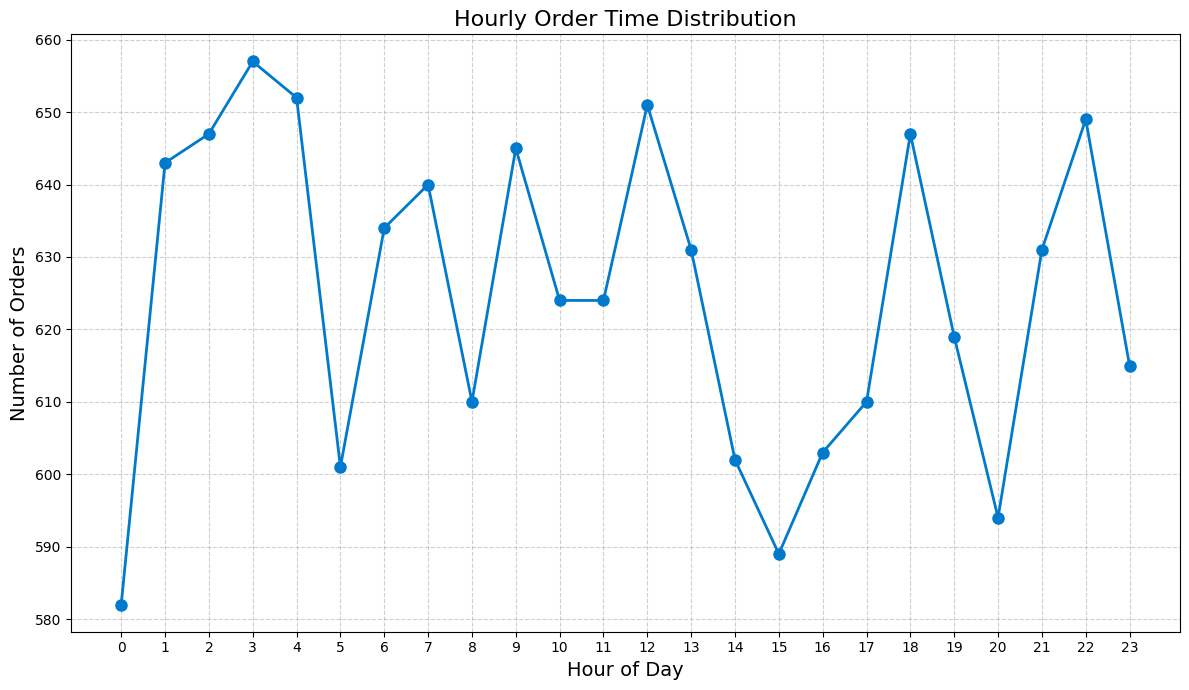

In [ ]:

# Re-calculate order_counts to ensure it's up-to-date with the latest df
order_counts = df['Hour'].value_counts().sort_index()

# Create line chart
plt.figure(figsize=(12, 7))
plt.plot(order_counts.index, order_counts.values, marker='o', color='#007ACC', linestyle='-', linewidth=2, markersize=8) # Changed color
plt.xlabel('Hour of Day', fontsize=14) # Increased font size
plt.ylabel('Number of Orders', fontsize=14) # Increased font size
plt.title('Hourly Order Time Distribution', fontsize=16) # Changed title and increased font size
plt.xticks(range(0, 24), fontsize=10)  # Show all hours (0-23) and adjust font size
plt.yticks(fontsize=10) # Adjust font size
plt.grid(True, linestyle='--', alpha=0.6) # Adjust grid alpha
plt.tight_layout()

# Save the plot
plt.savefig('hourly_order_time_distribution.png', dpi=300) # Increased DPI for better resolution
plt.show()

In [ ]:
# The descriptive analysis on the above dataset

# Display descriptive statistics for numerical columns
print("\nDescriptive Statistics:")
print(merged_df.describe())

# Display information about the dataframe (data types, non-null values)
print("\nDataFrame Info:")
print(merged_df.info())

# Display the number of unique values in each column
print("\nNumber of Unique Values per Column:")
print(merged_df.nunique())

# Display the count of missing values in each column
print("\nMissing Values per Column:")
print(merged_df.isnull().sum())


Descriptive Statistics:
                          Order_Date           Qty  Coupon_Discount
count                          15000  15000.000000     15000.000000
mean   2024-09-03 19:34:16.319999744      5.500733        11.228000
min              2024-03-06 00:00:00      1.000000         0.000000
25%              2024-06-04 00:00:00      3.000000         0.000000
50%              2024-09-04 00:00:00      6.000000        15.000000
75%              2024-12-04 00:00:00      8.000000        15.000000
max              2025-03-06 00:00:00     10.000000        20.000000
std                              NaN      2.870636         7.413659

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Or_ID            15000 non-null  object        
 1   C_ID             15000 non-null  object        
 2   P_ID             150

In [ ]:
# Linear Regression: Predict Qty using Coupon_Discount from a table and  Price from a different dataset.
# Formula: Qty = β0 + β1 * Coupon_Discount + β2 * Price + ε.

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import numpy as np

# Assuming merged_df is the DataFrame with 'Qty' and 'Coupon_Discount'
# and df is the DataFrame from sheet 1 with 'P_ID' and 'Price'
# We need to merge these two DataFrames on a common key, let's assume 'P_ID' is that key
# First, load the product information DataFrame again if not already available in the current scope
try:
  # Check if product_info_df is already defined
  product_info_df
except NameError:
  # Load the product info DataFrame if not defined
  product_info_df = pd.read_excel('/content/drive/MyDrive/zepto/Zepto_Dataset.xlsx', sheet_name=1) # Assuming sheet 1 has product info

# Merge merged_df with product_info_df to get 'Price' based on 'P_ID'
# Assuming 'merged_df' has a column 'P_ID' to join with 'product_info_df'
# If 'merged_df' doesn't have 'P_ID', you'll need to adjust the merge key based on your data structure.
# For this example, let's assume 'merged_df' has 'P_ID'
if 'P_ID' in merged_df.columns:
    # Ensure 'Price' is in the product_info_df
    if 'Price' in product_info_df.columns:
        # Select relevant columns for the merge to avoid duplicate columns or confusion
        product_price_df = product_info_df[['P_ID', 'Price']].copy()

        # Merge merged_df with product_price_df
        # Using a left merge to keep all rows from merged_df
        merged_df_with_price = pd.merge(merged_df, product_price_df, on='P_ID', how='left')

        # Drop rows where 'Price' is missing after the merge (products not found in price data)
        merged_df_with_price.dropna(subset=['Price', 'Qty', 'Coupon_Discount'], inplace=True)


        # Define the features (X) and the target variable (y)
        X = merged_df_with_price[['Coupon_Discount', 'Price']]
        y = merged_df_with_price['Qty']

        # Handle potential infinite values in features or target
        X = X.replace([np.inf, -np.inf], np.nan)
        y = y.replace([np.inf, -np.inf], np.nan)

        # Drop rows with NaN values introduced by replacement
        nan_rows = X.isnull().any(axis=1) | y.isnull()
        X = X[~nan_rows]
        y = y[~nan_rows]

        # Check if there's enough data to proceed after cleaning
        if len(X) > 0 and len(y) > 0 and len(X) == len(y):
            # Split the data into training and testing sets
            X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

            # Create a Linear Regression model
            model = LinearRegression()

            # Train the model
            model.fit(X_train, y_train)

            # Get the coefficients and intercept
            beta_0 = model.intercept_
            beta_1 = model.coef_[0]  # Coefficient for Coupon_Discount
            beta_2 = model.coef_[1]  # Coefficient for Price

            print(f"\nLinear Regression Model:")
            print(f"Formula: Qty = β0 + β1 * Coupon_Discount + β2 * Price + ε")
            print(f"β0 (Intercept): {beta_0:.4f}")
            print(f"β1 (Coefficient for Coupon_Discount): {beta_1:.4f}")
            print(f"β2 (Coefficient for Price): {beta_2:.4f}")

            # Optionally, evaluate the model on the test set
            score = model.score(X_test, y_test)
            print(f"Model R-squared on Test Set: {score:.4f}")

        else:
            print("Not enough valid data after cleaning for Linear Regression.")

    else:
        print("'Price' column not found in the product information dataset.")
else:
    print("'P_ID' column not found in the merged dataset ('merged_df'). Cannot perform the merge for price data.")



Linear Regression Model:
Formula: Qty = β0 + β1 * Coupon_Discount + β2 * Price + ε
β0 (Intercept): 5.4246
β1 (Coefficient for Coupon_Discount): 0.0039
β2 (Coefficient for Price): 0.0000
Model R-squared on Test Set: -0.0014


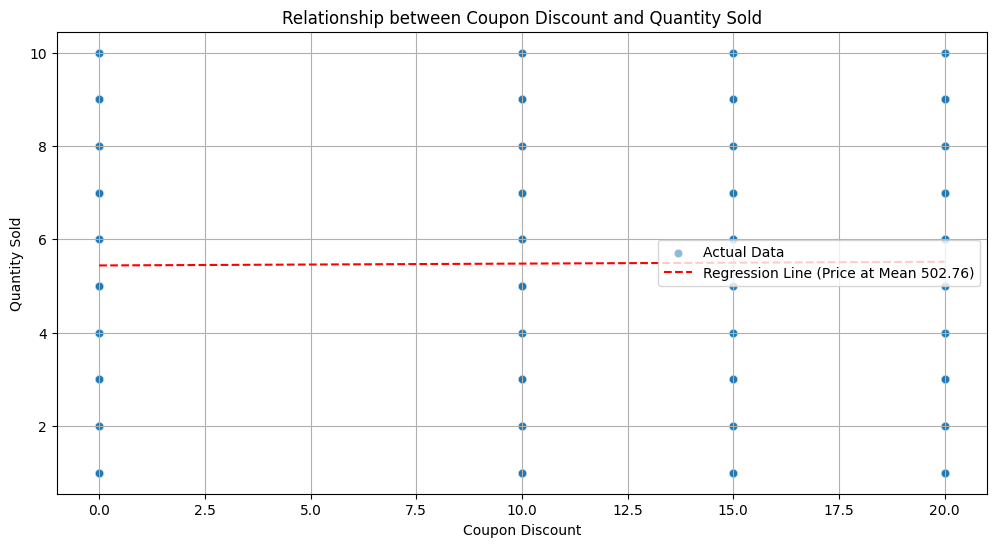

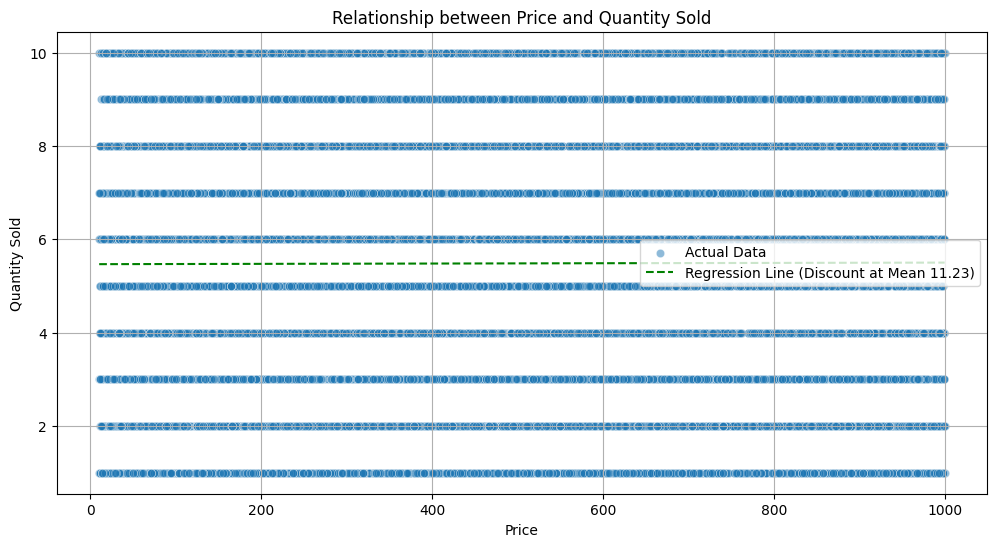

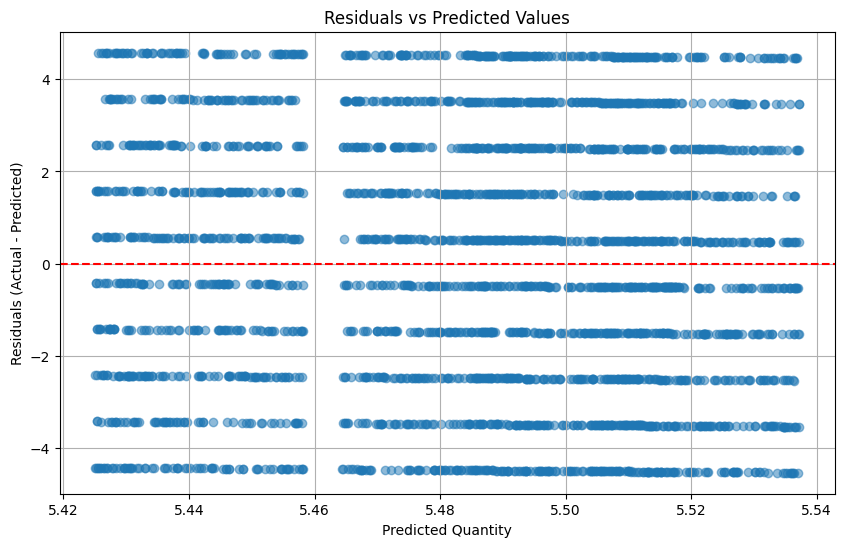

In [ ]:
# Visualization for the above linear regression model

# Visualize the relationship between features and target, and the model's predictions

# Scatter plot of Coupon_Discount vs Qty with regression line
plt.figure(figsize=(12, 6))
sns.scatterplot(x='Coupon_Discount', y='Qty', data=merged_df_with_price, alpha=0.5, label='Actual Data')
# Add the regression line for the relationship between Coupon_Discount and Qty, keeping Price constant (e.g., at its mean)
# This is a simplification as it's a multiple regression, but helps visualize the partial relationship.
mean_price = merged_df_with_price['Price'].mean()
x_values_discount = np.linspace(merged_df_with_price['Coupon_Discount'].min(), merged_df_with_price['Coupon_Discount'].max(), 100)
# Predicted Qty = beta_0 + beta_1 * Coupon_Discount + beta_2 * mean_price
y_pred_discount = beta_0 + beta_1 * x_values_discount + beta_2 * mean_price
plt.plot(x_values_discount, y_pred_discount, color='red', linestyle='--', label=f'Regression Line (Price at Mean {mean_price:.2f})')
plt.title('Relationship between Coupon Discount and Quantity Sold')
plt.xlabel('Coupon Discount')
plt.ylabel('Quantity Sold')
plt.legend()
plt.grid(True)
plt.show()

# Scatter plot of Price vs Qty with regression line
plt.figure(figsize=(12, 6))
sns.scatterplot(x='Price', y='Qty', data=merged_df_with_price, alpha=0.5, label='Actual Data')
# Add the regression line for the relationship between Price and Qty, keeping Coupon_Discount constant (e.g., at its mean)
mean_discount = merged_df_with_price['Coupon_Discount'].mean()
x_values_price = np.linspace(merged_df_with_price['Price'].min(), merged_df_with_price['Price'].max(), 100)
# Predicted Qty = beta_0 + beta_1 * mean_discount + beta_2 * Price
y_pred_price = beta_0 + beta_1 * mean_discount + beta_2 * x_values_price
plt.plot(x_values_price, y_pred_price, color='green', linestyle='--', label=f'Regression Line (Discount at Mean {mean_discount:.2f})')
plt.title('Relationship between Price and Quantity Sold')
plt.xlabel('Price')
plt.ylabel('Quantity Sold')
plt.legend()
plt.grid(True)
plt.show()

# 3D Scatter plot if possible (requires more libraries and might be complex)
# from mpl_toolkits.mplot3d import Axes3D
# fig = plt.figure(figsize=(10, 8))
# ax = fig.add_subplot(111, projection='3d')
# ax.scatter(merged_df_with_price['Coupon_Discount'], merged_df_with_price['Price'], merged_df_with_price['Qty'])
# ax.set_xlabel('Coupon_Discount')
# ax.set_ylabel('Price')
# ax.set_zlabel('Qty')
# plt.title('3D Scatter Plot of Coupon Discount, Price, and Quantity')
# plt.show()

# Alternatively, plot the residuals
# Get predictions for the test set
y_pred_test = model.predict(X_test)

# Calculate residuals
residuals = y_test - y_pred_test

# Plot residuals vs predicted values
plt.figure(figsize=(10, 6))
plt.scatter(y_pred_test, residuals, alpha=0.5)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Quantity')
plt.ylabel('Residuals (Actual - Predicted)')
plt.title('Residuals vs Predicted Values')
plt.grid(True)
plt.show()


In [ ]:
# the accuracy , precission , f-1 score, support for the above model

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Make predictions on the test set
y_pred_test = model.predict(X_test)

# Calculate metrics
r2 = r2_score(y_test, y_pred_test)
mae = mean_absolute_error(y_test, y_pred_test)
mse = mean_squared_error(y_test, y_pred_test)
rmse = np.sqrt(mse)

print("\nModel Evaluation Metrics on Test Set:")
print(f"R-squared (Accuracy equivalent for regression): {r2:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")

# Note: For regression problems like predicting quantity, metrics like
# Accuracy, Precision, F1-score, and Support are typically used for
# classification tasks. R-squared, MAE, MSE, and RMSE are appropriate
# metrics for evaluating the performance of a regression model.



Model Evaluation Metrics on Test Set:
R-squared (Accuracy equivalent for regression): -0.0014
Mean Absolute Error (MAE): 2.4833
Mean Squared Error (MSE): 8.1766
Root Mean Squared Error (RMSE): 2.8595


In [ ]:
# Test how changes in Price affect Qty using demand elasticity (requires regression).

# The code already performs a linear regression to model the relationship
# between 'Qty' (Quantity Sold) as the target variable (y) and
# 'Price' and 'Coupon_Discount' as features (X).

# The coefficient for 'Price' (beta_2) directly indicates how a unit change
# in Price is associated with a change in Quantity Sold, *holding Coupon_Discount constant*.
# This coefficient is calculated and printed in the existing code:
# print(f"β2 (Coefficient for Price): {beta_2:.4f}")

# A negative beta_2 would suggest that as Price increases, Quantity Sold decreases,
# which is consistent with the law of demand. The magnitude of beta_2
# indicates the steepness of this relationship.

# To calculate price elasticity of demand, we typically use the formula:
# E_d = (% Change in Quantity Demanded) / (% Change in Price)
# E_d = (ΔQ / Q) / (ΔP / P)
# E_d = (ΔQ / ΔP) * (P / Q)

# From the linear regression model (Qty = β0 + β1 * Discount + β2 * Price),
# the change in Quantity (ΔQ) for a given change in Price (ΔP), holding Discount constant,
# is given by β2. So, ΔQ / ΔP = β2.

# Therefore, Elasticity of Demand (E_d) can be estimated as:
# E_d = β2 * (Average Price / Average Quantity)

# Let's calculate the average price and average quantity from the dataset used for regression.
# This should be done on the dataset *after* cleaning and merging: merged_df_with_price

if 'merged_df_with_price' in locals():
    if len(merged_df_with_price) > 0:
        average_price = merged_df_with_price['Price'].mean()
        average_qty = merged_df_with_price['Qty'].mean()

        # Ensure beta_2 was calculated in the previous regression step
        if 'beta_2' in locals():
            # Calculate the price elasticity of demand
            if average_qty != 0: # Avoid division by zero
                price_elasticity = beta_2 * (average_price / average_qty)

                print(f"\nEstimated Price Elasticity of Demand:")
                print(f"Average Price: {average_price:.4f}")
                print(f"Average Quantity: {average_qty:.4f}")
                print(f"Beta_2 (Price Coefficient): {beta_2:.4f}")
                print(f"Estimated Elasticity (E_d): {price_elasticity:.4f}")

                # Interpretation of Elasticity:
                if price_elasticity < -1:
                    print("Interpretation: Demand is Elastic (E_d < -1). A 1% increase in price leads to a more than 1% decrease in quantity demanded.")
                elif price_elasticity > -1 and price_elasticity < 0:
                     print("Interpretation: Demand is Inelastic (-1 < E_d < 0). A 1% increase in price leads to a less than 1% decrease in quantity demanded.")
                elif price_elasticity == -1:
                    print("Interpretation: Demand is Unit Elastic (E_d = -1). A 1% change in price leads to a 1% change in quantity demanded.")
                elif price_elasticity >= 0:
                     print("Interpretation: The calculated elasticity is non-negative, which is not typical for standard goods (where price increases usually decrease demand). Check data or model assumptions.")


            else:
                print("Average Quantity is zero, cannot calculate Price Elasticity.")
        else:
            print("Beta_2 (Price Coefficient) was not calculated. Run the linear regression first.")

    else:
        print("The DataFrame 'merged_df_with_price' is empty after cleaning. Cannot calculate elasticity.")
else:
    print("The DataFrame 'merged_df_with_price' is not defined. Ensure the merge and regression steps ran successfully.")

# This calculation provides a single point estimate of elasticity based on the average price and quantity.
# Elasticity can vary along the demand curve.



Estimated Price Elasticity of Demand:
Average Price: 502.7623
Average Quantity: 5.5007
Beta_2 (Price Coefficient): 0.0000
Estimated Elasticity (E_d): 0.0031
Interpretation: The calculated elasticity is non-negative, which is not typical for standard goods (where price increases usually decrease demand). Check data or model assumptions.


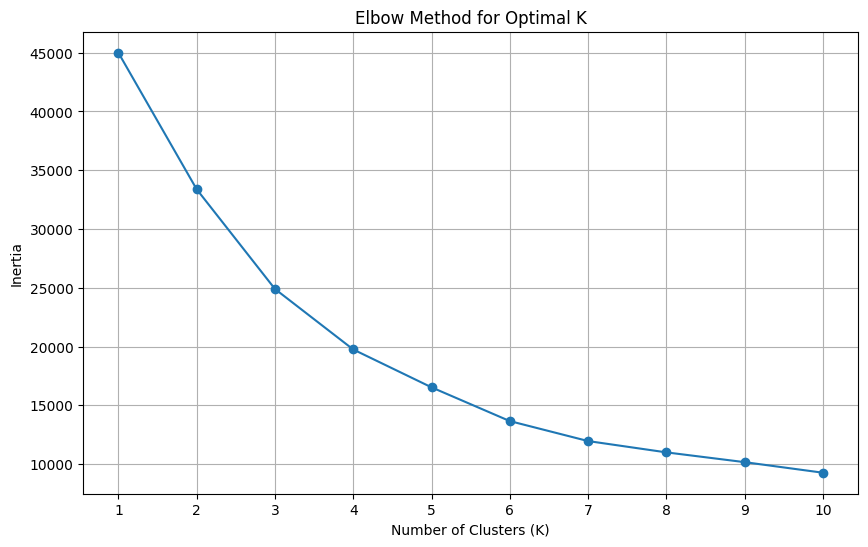


Running K-Means clustering with K = 3

DataFrame with Cluster Assignments:
   Qty   Price  Coupon_Discount  Cluster
0    3  142.25               15        2
1   10   90.75               10        1
2   10  152.27                0        0
3    9  599.19               10        1
4    4   90.97               10        2

Cluster Analysis (Mean of Features per Cluster):
              Qty       Price  Coupon_Discount
Cluster                                       
0        5.494717  497.198093         0.000000
1        7.991821  501.301887        15.045341
2        2.998569  508.000100        14.991950


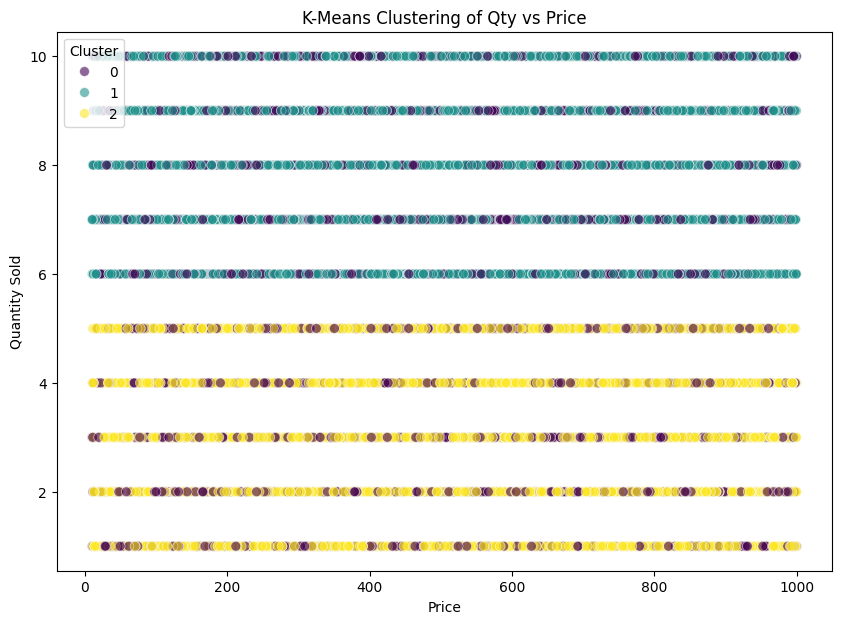

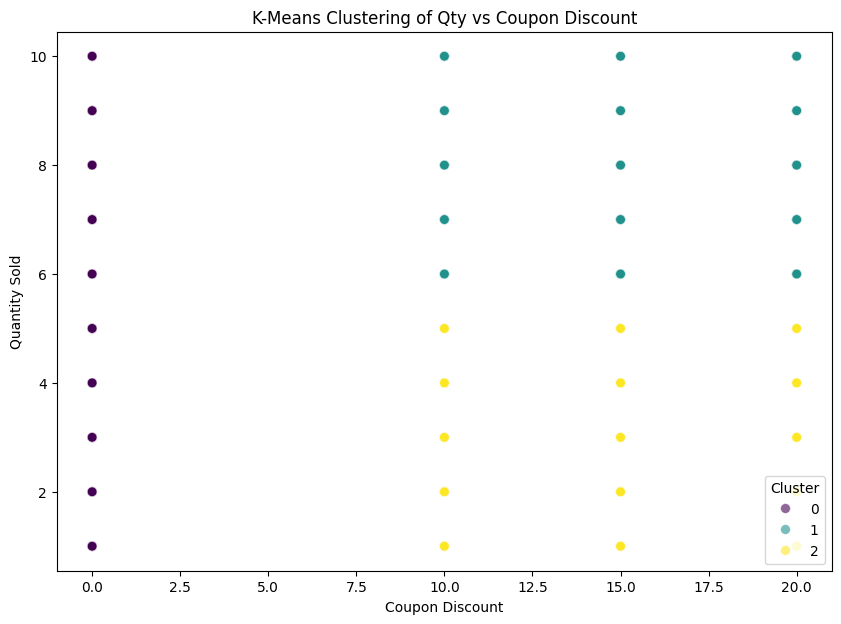

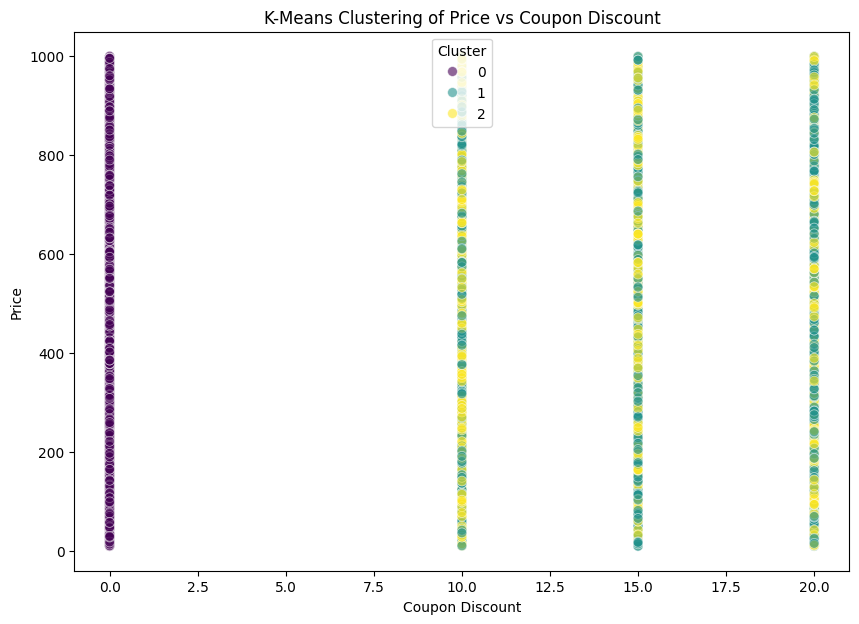

In [ ]:
#  K-Means Clustering for the above dataset

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Select features for clustering.
# Let's use numerical features like 'Qty', 'Price', 'Coupon_Discount'.
# We need to ensure 'merged_df_with_price' is the correct DataFrame containing these columns.
# From the preceding code, merged_df_with_price contains 'Qty', 'Price', and 'Coupon_Discount'.

clustering_features = merged_df_with_price[['Qty', 'Price', 'Coupon_Discount']].copy()

# Handle potential missing values in the selected features before scaling and clustering
clustering_features.dropna(inplace=True)

# Check if there's enough data after dropping NaNs
if len(clustering_features) > 0:
    # Standardize the features
    scaler = StandardScaler()
    scaled_features = scaler.fit_transform(clustering_features)

    # Determine the optimal number of clusters (K) using the Elbow method
    inertia = []
    k_range = range(1, 11) # Test K from 1 to 10

    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10) # Added n_init for robustness
        kmeans.fit(scaled_features)
        inertia.append(kmeans.inertia_)

    # Plot the Elbow method graph
    plt.figure(figsize=(10, 6))
    plt.plot(k_range, inertia, marker='o')
    plt.title('Elbow Method for Optimal K')
    plt.xlabel('Number of Clusters (K)')
    plt.ylabel('Inertia')
    plt.xticks(k_range)
    plt.grid(True)
    plt.show()

    # Based on the Elbow plot, choose an appropriate number of clusters.
    # For demonstration, let's choose K=3 (adjust based on the plot)
    optimal_k = 3 # Example: replace with the value observed from the elbow plot

    print(f"\nRunning K-Means clustering with K = {optimal_k}")

    # Apply K-Means clustering with the chosen K
    kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10) # Added n_init
    clusters = kmeans.fit_predict(scaled_features)

    # Add the cluster labels back to the original dataframe (or the dataframe used for clustering)
    # We need to align the cluster labels with the original rows from merged_df_with_price
    # since we dropped rows with NaNs.
    merged_df_with_price_clustered = merged_df_with_price.copy()
    merged_df_with_price_clustered['Cluster'] = -1 # Initialize with a placeholder

    # Assign cluster labels to the corresponding rows
    # The indices of scaled_features correspond to the indices of clustering_features
    merged_df_with_price_clustered.loc[clustering_features.index, 'Cluster'] = clusters

    # Display the first few rows with cluster assignments
    print("\nDataFrame with Cluster Assignments:")
    print(merged_df_with_price_clustered[['Qty', 'Price', 'Coupon_Discount', 'Cluster']].head())

    # Analyze the characteristics of each cluster
    print("\nCluster Analysis (Mean of Features per Cluster):")
    print(merged_df_with_price_clustered.groupby('Cluster')[['Qty', 'Price', 'Coupon_Discount']].mean())

    # You can further visualize the clusters (e.g., using scatter plots of pairs of features, colored by cluster)
    # For example, plotting Qty vs Price, colored by Cluster
    plt.figure(figsize=(10, 7))
    sns.scatterplot(x='Price', y='Qty', hue='Cluster', data=merged_df_with_price_clustered, palette='viridis', s=50, alpha=0.6)
    plt.title('K-Means Clustering of Qty vs Price')
    plt.xlabel('Price')
    plt.ylabel('Quantity Sold')
    plt.show()

    # Plotting Qty vs Coupon_Discount, colored by Cluster
    plt.figure(figsize=(10, 7))
    sns.scatterplot(x='Coupon_Discount', y='Qty', hue='Cluster', data=merged_df_with_price_clustered, palette='viridis', s=50, alpha=0.6)
    plt.title('K-Means Clustering of Qty vs Coupon Discount')
    plt.xlabel('Coupon Discount')
    plt.ylabel('Quantity Sold')
    plt.show()

    # Plotting Price vs Coupon_Discount, colored by Cluster
    plt.figure(figsize=(10, 7))
    sns.scatterplot(x='Coupon_Discount', y='Price', hue='Cluster', data=merged_df_with_price_clustered, palette='viridis', s=50, alpha=0.6)
    plt.title('K-Means Clustering of Price vs Coupon Discount')
    plt.xlabel('Coupon Discount')
    plt.ylabel('Price')
    plt.show()

    # Note: Visualizing 3+ dimensions directly is hard. You can use PCA or t-SNE for dimensionality reduction
    # before plotting if you have more features.

else:
    print("\nNo valid data points available for K-Means clustering after handling missing values in the selected features.")



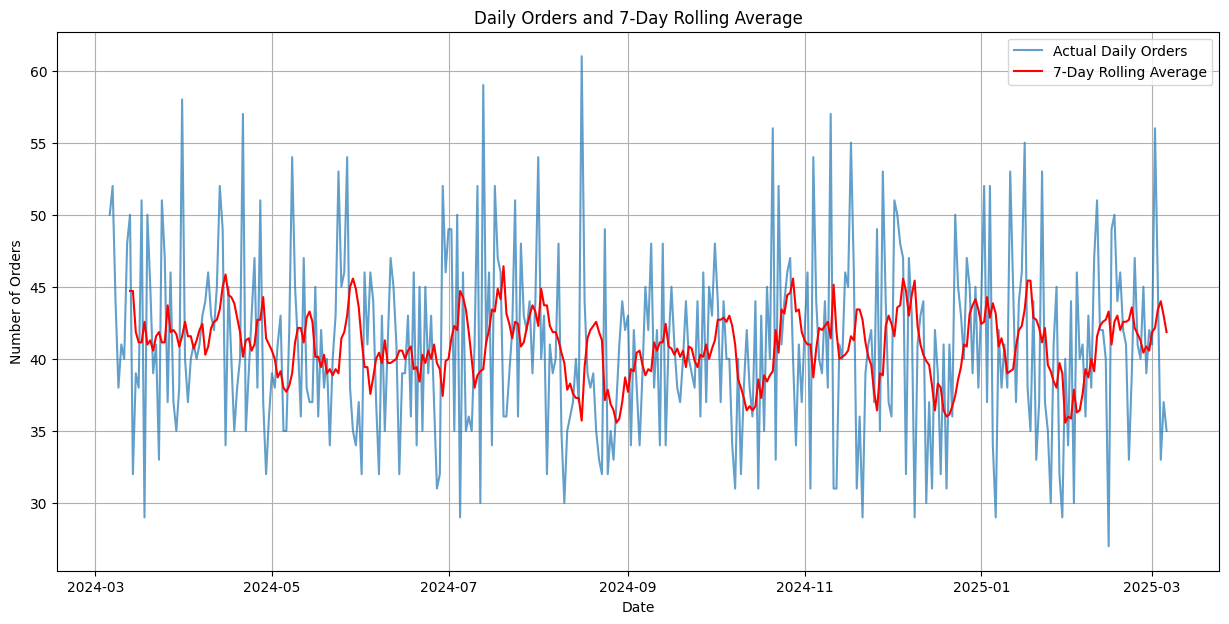


Simple 7-Day Forecast based on Last Rolling Average:
            Forecasted_Orders
2025-03-07          41.857143
2025-03-08          41.857143
2025-03-09          41.857143
2025-03-10          41.857143
2025-03-11          41.857143
2025-03-12          41.857143
2025-03-13          41.857143

Assuming next day's total forecast is: 35

Hourly Forecast Distribution for Next Day based on Historical Proportions:
Hour
0     1.0
1     2.0
2     2.0
3     2.0
4     2.0
5     1.0
6     1.0
7     1.0
8     1.0
9     2.0
10    1.0
11    1.0
12    2.0
13    1.0
14    1.0
15    1.0
16    1.0
17    1.0
18    2.0
19    1.0
20    1.0
21    1.0
22    2.0
23    1.0
Name: proportion, dtype: float64


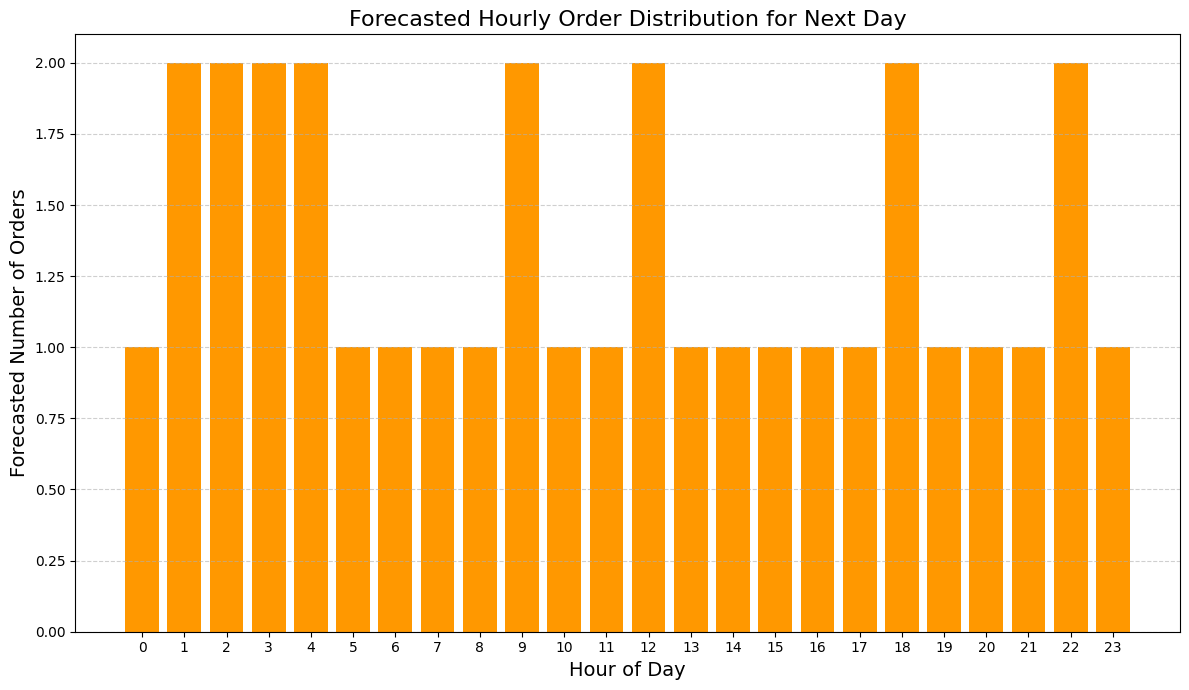

In [ ]:
# Forecast future orders based on Order_Date or Order_Time for the above dataset

# Convert 'Order_Date' to datetime objects
merged_df['Order_Date'] = pd.to_datetime(merged_df['Order_Date'])

# Group by 'Order_Date' and count the number of orders
daily_orders = merged_df.groupby('Order_Date').size().reset_index(name='Order_Count')

# Sort by date
daily_orders = daily_orders.sort_values(by='Order_Date')

# Set 'Order_Date' as the index for time series analysis
daily_orders = daily_orders.set_index('Order_Date')

# Resample the data to a daily frequency (if not already) and fill missing days with 0
daily_orders = daily_orders.resample('D').sum()

# For simple forecasting, we can use rolling averages or a simple time series model.
# A more robust approach would involve ARIMA, Prophet, or other time series forecasting methods.
# Let's use a simple rolling average as a basic illustration.

# Calculate a rolling average of orders (e.g., 7-day rolling average)
daily_orders['Rolling_Average_7_Days'] = daily_orders['Order_Count'].rolling(window=7).mean().shift(1) # Shift by 1 to avoid look-ahead bias

# Visualize the time series and the rolling average
plt.figure(figsize=(15, 7))
plt.plot(daily_orders.index, daily_orders['Order_Count'], label='Actual Daily Orders', alpha=0.7)
plt.plot(daily_orders.index, daily_orders['Rolling_Average_7_Days'], label='7-Day Rolling Average', color='red')
plt.title('Daily Orders and 7-Day Rolling Average')
plt.xlabel('Date')
plt.ylabel('Number of Orders')
plt.legend()
plt.grid(True)
plt.show()

# To forecast future orders based on this simple method:
# The last value of the rolling average can be used as a forecast for the next day,
# or you can extend the rolling average calculation.

# Let's demonstrate forecasting the next 7 days using the last rolling average value
last_rolling_avg = daily_orders['Rolling_Average_7_Days'].iloc[-1]
last_date = daily_orders.index[-1]

# Create future dates
future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=7, freq='D')

# Create a simple forecast DataFrame
forecast_df = pd.DataFrame({'Forecasted_Orders': [last_rolling_avg] * 7}, index=future_dates)

print("\nSimple 7-Day Forecast based on Last Rolling Average:")
print(forecast_df)

# Note: This is a very basic forecasting method. For real-world applications,
# consider more sophisticated time series models (like ARIMA, SARIMA, Prophet)
# that can capture seasonality, trends, and other patterns.

# Using Order_Time distribution for future orders prediction is more about
# understanding the *pattern within a day* rather than forecasting future *days*.
# The previous hourly order distribution chart already shows this pattern.
# You could use this hourly pattern to distribute forecasted daily orders
# into hourly forecasts for the next day.

# Example: If you forecast 1000 orders for tomorrow, and historically 10%
# of orders happen between 9 AM and 10 AM, you might forecast 100 orders
# for that hour tomorrow.

# To do this:
# 1. Calculate the proportion of orders for each hour from historical data.
hourly_proportions = df['Hour'].value_counts(normalize=True).sort_index()

# 2. Get your daily forecast (e.g., from the rolling average or another model).
# Let's use the last day's actual order count or the last rolling average as a simple example for the "next day's forecast"
# In a real scenario, this would come from a robust time series forecast model.
next_day_forecast_total = daily_orders['Order_Count'].iloc[-1] # Example: Use last actual day's count
# Or: next_day_forecast_total = last_rolling_avg # Example: Use last rolling average

print(f"\nAssuming next day's total forecast is: {next_day_forecast_total:.0f}")

# 3. Distribute the total daily forecast across hours based on historical proportions.
hourly_forecast_next_day = (hourly_proportions * next_day_forecast_total).round(0) # Round to whole numbers

print("\nHourly Forecast Distribution for Next Day based on Historical Proportions:")
print(hourly_forecast_next_day)

# Visualize the forecasted hourly distribution
plt.figure(figsize=(12, 7))
plt.bar(hourly_forecast_next_day.index, hourly_forecast_next_day.values, color='#FF9800') # Changed color
plt.xlabel('Hour of Day', fontsize=14)
plt.ylabel('Forecasted Number of Orders', fontsize=14)
plt.title('Forecasted Hourly Order Distribution for Next Day', fontsize=16)
plt.xticks(range(0, 24), fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# This combines the concept of forecasting *when* future orders might occur (based on hourly patterns)
# with a simple method for forecasting the total number of orders *in the future*.

the related objectives for above information



Customer Segmentation by Age Group:
  Age_Group  Customer_Count
0      0-17               0
1     18-29            3534
2     30-44            4139
3     45-59            4212
4       60+            3115


<ipython-input-63-109057995cde>:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_segmentation = new_df.groupby('Age_Group').size().reset_index(name='Customer_Count')
<ipython-input-63-109057995cde>:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Age_Group', y='Customer_Count', data=age_segmentation, palette='viridis')


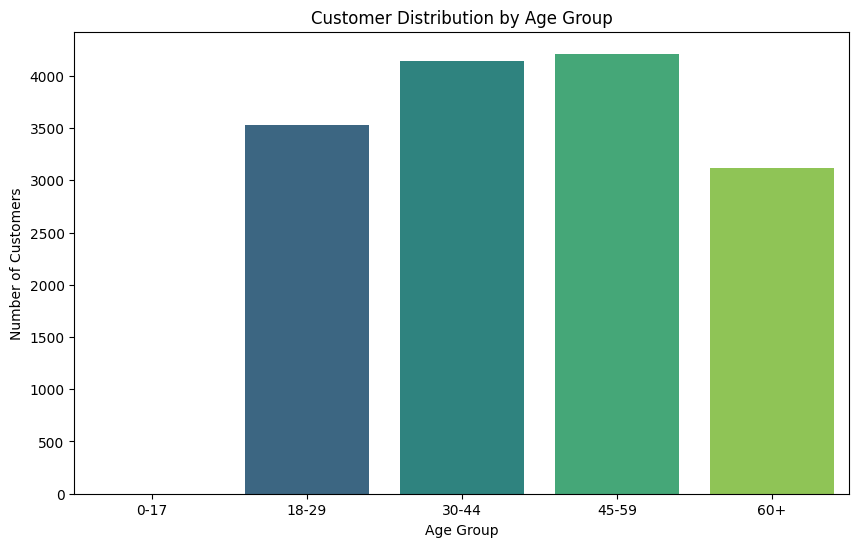


Customer Segmentation by Gender:
   gender  Customer_Count
0  Female            7470
1    Male            7530


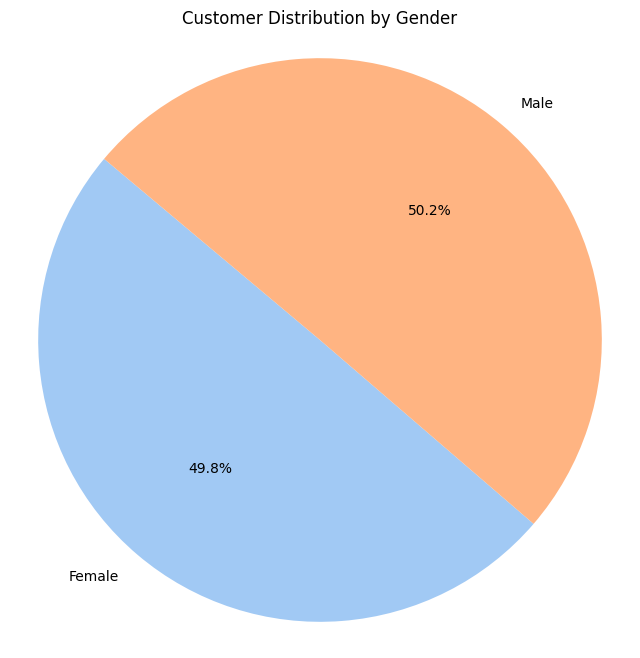


Customer Segmentation by State:
             State  Customer_Count
11          Odisha             874
8           Kerala             866
7        Karnataka             862
3     Chhattisgarh             861
16   Uttar Pradesh             859
5          Haryana             859
9   Madhya Pradesh             858
14      Tamil Nadu             850
4          Gujarat             832
10     Maharashtra             829
6        Jharkhand             827
1            Assam             825
12          Punjab             822
13       Rajasthan             812
2            Bihar             801
17     West Bengal             800
0   Andhra Pradesh             792
15       Telangana             771


<ipython-input-63-109057995cde>:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='State', y='Customer_Count', data=state_segmentation_top, palette='viridis')


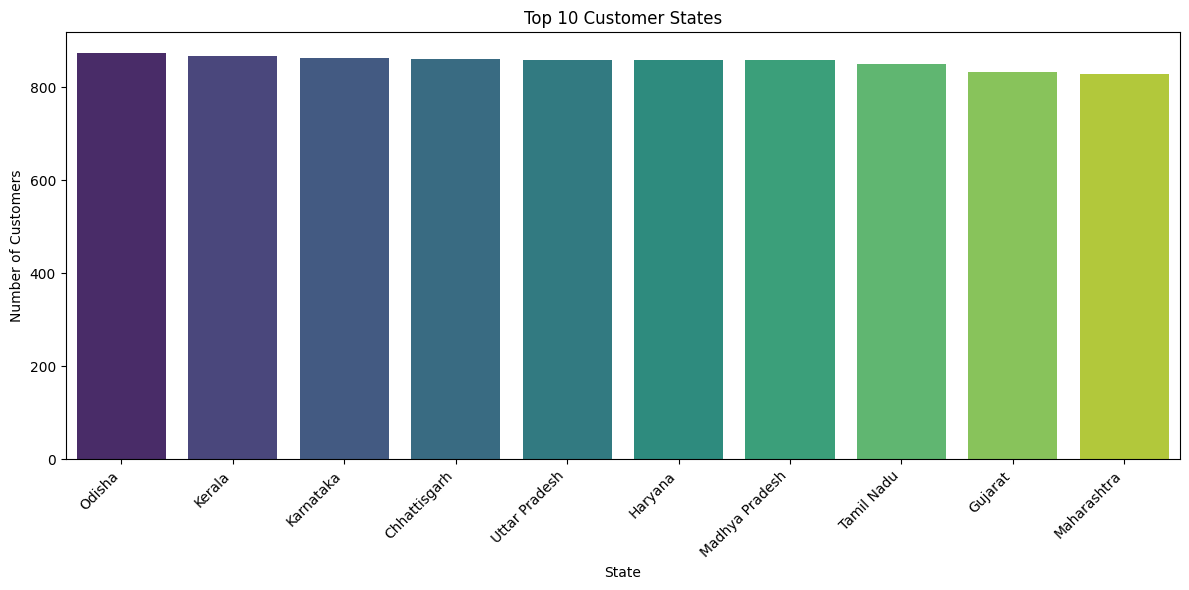


'City' column not found in 'merged_df'. Cannot perform Order segmentation by City.

Order Segmentation by Coupon Usage:
      Coupon_Used  Order_Count
0  No Coupon Used         3786
1     Coupon Used        11214


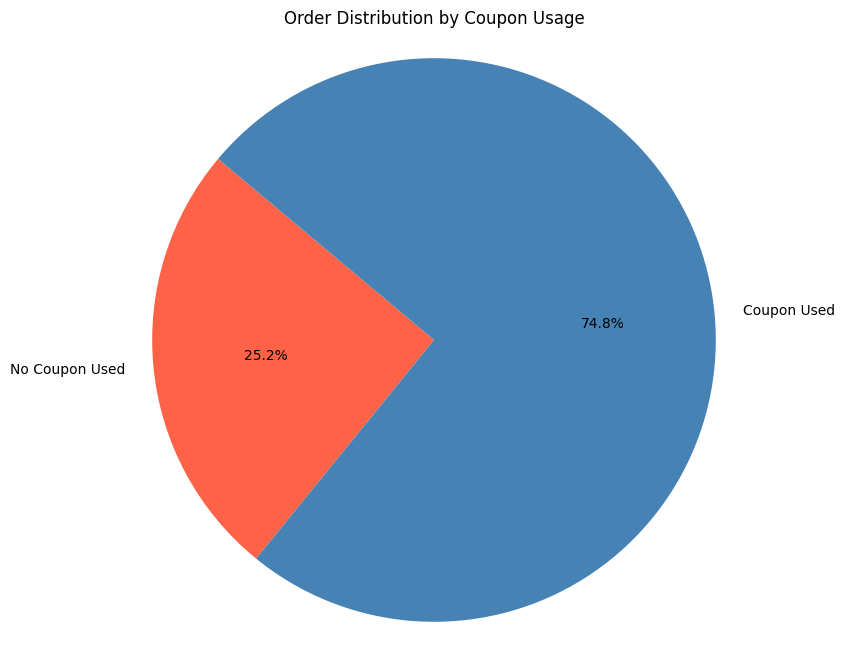


Order Segmentation by Product (P_ID):
             P_ID  Order_Count
5150  PD_21008237           10
1753  PD_21002819           10
5247  PD_21008390           10
3999  PD_21006446           10
5363  PD_21008582            9


<ipython-input-63-109057995cde>:157: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=x_col, y='Order_Count', data=product_order_segmentation_top_with_category, palette='magma')


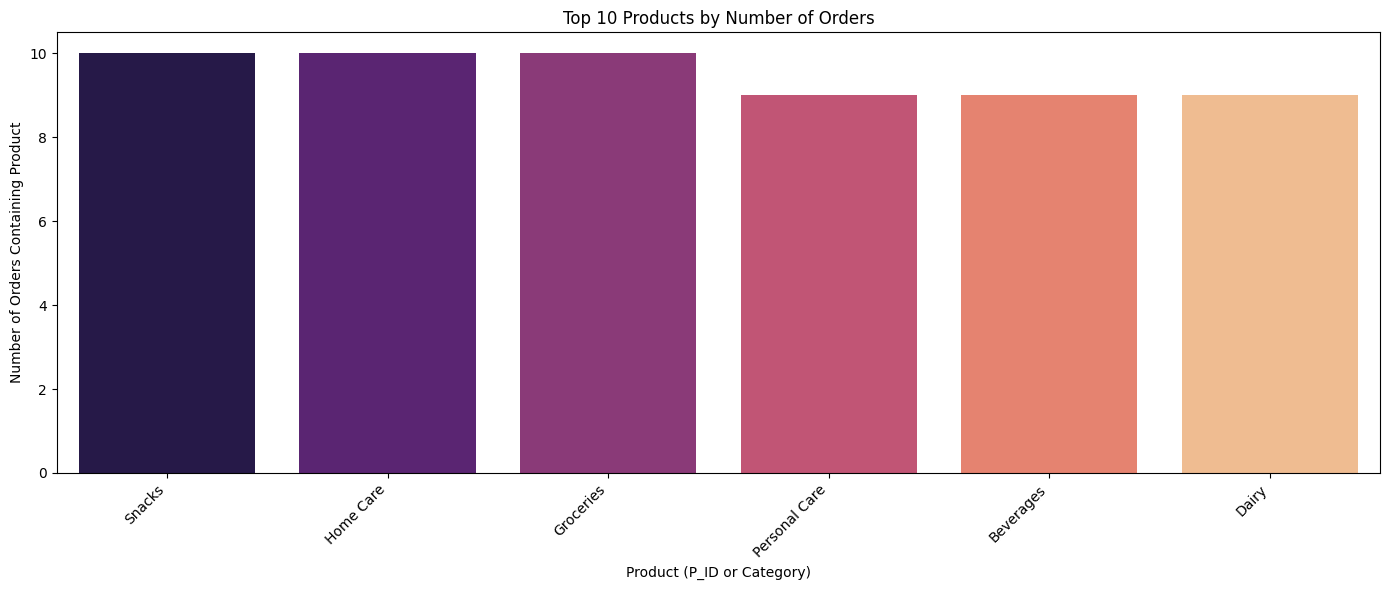

In [ ]:
# Group customers or orders by attributes.
# Implementation:
# Customer Segmentation: By Age (e.g., 18–30, 31–45), gender, State.
# Order Segmentation: By City, Coupon, or P_ID.

# Customer Segmentation by Age Groups
# Define age bins and labels
age_bins = [0, 18, 30, 45, 60, 100] # Example bins: 0-17, 18-29, 30-44, 45-59, 60+
age_labels = ['0-17', '18-29', '30-44', '45-59', '60+']

# Create a new column 'Age_Group' based on 'Age'
# Using the new_df which contains 'C_ID', 'gender', 'Age', 'City', 'State'
if 'Age' in new_df.columns:
    new_df['Age_Group'] = pd.cut(new_df['Age'], bins=age_bins, labels=age_labels, right=False) # right=False means [lower, upper)

    # Group by Age Group and count customers
    age_segmentation = new_df.groupby('Age_Group').size().reset_index(name='Customer_Count')

    print("\nCustomer Segmentation by Age Group:")
    print(age_segmentation)

    # Visualize Age Group Segmentation
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Age_Group', y='Customer_Count', data=age_segmentation, palette='viridis')
    plt.title('Customer Distribution by Age Group')
    plt.xlabel('Age Group')
    plt.ylabel('Number of Customers')
    plt.show()
else:
    print("\n'Age' column not found in 'new_df'. Cannot perform Age Group segmentation.")


# Customer Segmentation by Gender
# Group by Gender and count customers
if 'gender' in new_df.columns:
    gender_segmentation = new_df.groupby('gender').size().reset_index(name='Customer_Count')

    print("\nCustomer Segmentation by Gender:")
    print(gender_segmentation)

    # Visualize Gender Segmentation (e.g., Pie Chart or Bar Chart)
    plt.figure(figsize=(8, 8))
    plt.pie(gender_segmentation['Customer_Count'], labels=gender_segmentation['gender'], autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
    plt.title('Customer Distribution by Gender')
    plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
    plt.show()
else:
    print("\n'gender' column not found in 'new_df'. Cannot perform Gender segmentation.")

# Customer Segmentation by State
# Group by State and count customers
if 'State' in new_df.columns:
    state_segmentation = new_df.groupby('State').size().reset_index(name='Customer_Count')

    print("\nCustomer Segmentation by State:")
    print(state_segmentation.sort_values(by='Customer_Count', ascending=False)) # Show top states

    # Visualize Top N States Segmentation
    top_n_states = 10 # Display top 10 states
    state_segmentation_top = state_segmentation.sort_values(by='Customer_Count', ascending=False).head(top_n_states)

    plt.figure(figsize=(12, 6))
    sns.barplot(x='State', y='Customer_Count', data=state_segmentation_top, palette='viridis')
    plt.title(f'Top {top_n_states} Customer States')
    plt.xlabel('State')
    plt.ylabel('Number of Customers')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("\n'State' column not found in 'new_df'. Cannot perform State segmentation.")


# Assuming merged_df is the DataFrame containing order information and potentially customer info
# Order Segmentation by City
# Group by City and count orders
if 'City' in merged_df.columns:
    city_order_segmentation = merged_df.groupby('City').size().reset_index(name='Order_Count')

    print("\nOrder Segmentation by City:")
    print(city_order_segmentation.sort_values(by='Order_Count', ascending=False).head()) # Show top cities by orders

    # Visualize Top N Cities by Orders
    top_n_cities = 10 # Display top 10 cities
    city_order_segmentation_top = city_order_segmentation.sort_values(by='Order_Count', ascending=False).head(top_n_cities)

    plt.figure(figsize=(12, 6))
    sns.barplot(x='City', y='Order_Count', data=city_order_segmentation_top, palette='plasma')
    plt.title(f'Top {top_n_cities} Cities by Number of Orders')
    plt.xlabel('City')
    plt.ylabel('Number of Orders')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("\n'City' column not found in 'merged_df'. Cannot perform Order segmentation by City.")


# Order Segmentation by Coupon Usage (assuming a binary or categorical 'Coupon' column or similar)
# Let's assume 'Coupon_Discount' is available in merged_df and we can group by whether a discount was applied (discount > 0)
if 'Coupon_Discount' in merged_df.columns:
    # Create a new column indicating if a coupon was used
    merged_df['Coupon_Used'] = merged_df['Coupon_Discount'] > 0

    # Group by Coupon_Used and count orders
    coupon_order_segmentation = merged_df.groupby('Coupon_Used').size().reset_index(name='Order_Count')
    coupon_order_segmentation['Coupon_Used'] = coupon_order_segmentation['Coupon_Used'].map({True: 'Coupon Used', False: 'No Coupon Used'})


    print("\nOrder Segmentation by Coupon Usage:")
    print(coupon_order_segmentation)

    # Visualize Coupon Usage Segmentation
    plt.figure(figsize=(8, 8))
    plt.pie(coupon_order_segmentation['Order_Count'], labels=coupon_order_segmentation['Coupon_Used'], autopct='%1.1f%%', startangle=140, colors=['#FF6347', '#4682B4'])
    plt.title('Order Distribution by Coupon Usage')
    plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
    plt.show()
else:
    print("\n'Coupon_Discount' column not found in 'merged_df'. Cannot perform Order segmentation by Coupon.")


# Order Segmentation by P_ID (Product) - Similar to the Top Products analysis
# Group by P_ID and count orders (or unique P_IDs within orders)
# Let's count the number of orders each product appears in
if 'P_ID' in merged_df.columns:
    product_order_count = merged_df.groupby('P_ID').size().reset_index(name='Order_Count')

    print("\nOrder Segmentation by Product (P_ID):")
    print(product_order_count.sort_values(by='Order_Count', ascending=False).head()) # Show top products by orders

    # Visualize Top N Products by Number of Orders
    top_n_products_by_orders = 10 # Display top 10 products
    product_order_segmentation_top = product_order_count.sort_values(by='Order_Count', ascending=False).head(top_n_products_by_orders)

    # To make the plot more readable, let's merge with product category if available
    try:
      product_info_df # Check if product_info_df from sheet 1 is available
    except NameError:
       product_info_df = pd.read_excel('/content/drive/MyDrive/zepto/Zepto_Dataset.xlsx', sheet_name=1) # Load if not

    if 'Category' in product_info_df.columns:
        product_order_segmentation_top_with_category = pd.merge(
            product_order_segmentation_top,
            product_info_df[['P_ID', 'Category']],
            on='P_ID',
            how='left'
        )
        # Use Category for plotting labels if available, fallback to P_ID
        product_order_segmentation_top_with_category['Plot_Label'] = product_order_segmentation_top_with_category['Category'].fillna(product_order_segmentation_top_with_category['P_ID'])
        x_col = 'Plot_Label'
    else:
        x_col = 'P_ID'
        product_order_segmentation_top_with_category = product_order_segmentation_top # Use original if no category

    plt.figure(figsize=(14, 6))
    sns.barplot(x=x_col, y='Order_Count', data=product_order_segmentation_top_with_category, palette='magma')
    plt.title(f'Top {top_n_products_by_orders} Products by Number of Orders')
    plt.xlabel('Product (P_ID or Category)')
    plt.ylabel('Number of Orders Containing Product')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

else:
    print("\n'P_ID' column not found in 'merged_df'. Cannot perform Order segmentation by P_ID.")